The next cells are mostly taken from the zoobot example in Colab, any changes will be explained with a comment.

In [3]:
# import packages

import logging
import os
import sys
import shutil
import pandas as pd

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

logging.basicConfig(level=logging.INFO)

In [4]:
import torch
torch.__version__

'2.6.0+cu124'

In [5]:
sys.path.append('/content/galaxy-datasets')
sys.path.append('/content/zoobot')
sys.path.append('/content/zoobot/pytorch')

In [6]:
from tqdm import tqdm
import urllib.request

df = pd.read_csv('/kaggle/input/dataframes/final_classified_sample_clusters.csv') # change path depending on where the catalog is

In [7]:
df.head()

,ls_id,cluster,classifications,disturbed_weighted_fraction,disturbed_unweighted_fraction,merger_weighted_fraction,merger_unweighted_fraction,tail_weighted_fraction,tail_unweighted_fraction,problem_weighted_fraction,...,snr_g,dered_mag_r,mag_r,snr_r,dered_mag_z,mag_z,snr_z,g_r,sersic,shape_r
0,9906602778170029,S0560,10.0,0.125,0.125,0.0,0.0,1.0,1.0,0.2,...,572.22560,17.849754,17.932308,849.5118,17.609100,17.655277,358.42822,0.449724,0.711966,5.261388
1,9906602826208740,S0560,10.0,0.100,0.100,0.0,0.0,1.0,1.0,0.0,...,364.17874,17.850813,17.956392,721.7412,17.261772,17.320827,462.55164,0.938601,1.938687,3.238290
2,9906602826210767,S0560,10.0,0.000,0.000,0.0,0.0,0.0,0.0,0.3,...,621.59753,16.944622,17.053755,970.4237,16.667028,16.728073,508.76932,0.534895,0.927683,5.335766
3,9906602826271183,S0560,10.0,0.100,0.100,0.0,0.0,1.0,1.0,0.0,...,551.37400,17.693842,17.790771,893.9220,17.254980,17.309196,507.14310,0.682962,1.392068,2.848009
4,9906602826271203,S0560,10.0,0.000,0.000,0.0,0.0,0.0,0.0,0.0,...,1285.42540,16.227610,16.325230,2234.2612,15.787631,15.842235,1660.99940,0.701353,2.243750,2.340032


In [8]:
# threshold definition

problem_threshold = 0.33
disturbed_threshold = 0.5 # before we had 0.39
merger_threshold = 0.23
tail_threshold = 0.37

not_jelly = df.loc[(df['disturbed_weighted_fraction'] < 0.2) | (df['tail_weighted_fraction'] < tail_threshold)  | (df['merger_weighted_fraction'] > merger_threshold)]
undisturbed = df.loc[(df['disturbed_weighted_fraction'] < disturbed_threshold) & (df['problem_weighted_fraction'] < problem_threshold)]
yes_jellies = df.loc[(df['disturbed_weighted_fraction'] > disturbed_threshold) & (df['problem_weighted_fraction'] < problem_threshold) & ((df['merger_weighted_fraction'] < merger_threshold) | (df['tail_weighted_fraction'] > tail_threshold)) ]
mergers = df.loc[(df['disturbed_weighted_fraction'] > disturbed_threshold) & (df['problem_weighted_fraction'] < problem_threshold) & (df['merger_weighted_fraction'] > merger_threshold)]

In [32]:
not_jelly.shape # check how many galaxies are not jellyfish

(30074, 39)

In [33]:
yes_jellies.shape # check how many galaxies are jellyfish

(2881, 39)

In [35]:
yes_jellies

,ls_id,cluster,classifications,disturbed_weighted_fraction,disturbed_unweighted_fraction,merger_weighted_fraction,merger_unweighted_fraction,tail_weighted_fraction,tail_unweighted_fraction,problem_weighted_fraction,...,snr_g,dered_mag_r,mag_r,snr_r,dered_mag_z,mag_z,snr_z,g_r,sersic,shape_r
18,9906602826469111,S0560,10.0,0.789474,0.800000,0.000000,0.000000,0.533333,0.500000,0.000000,...,2114.03200,15.510704,15.590949,3147.97120,15.035301,15.080187,1990.58220,0.632003,1.547828,6.231403
19,9906602826470195,S0560,10.0,0.700000,0.700000,0.000000,0.000000,1.000000,1.000000,0.000000,...,485.59558,18.340002,18.419825,576.04315,18.215893,18.260542,215.78708,0.314795,0.836684,4.940063
22,9906602874835231,S0560,10.0,0.555556,0.555556,0.000000,0.000000,0.400000,0.400000,0.100000,...,1390.03630,15.523657,15.614053,1812.22390,15.352885,15.403448,758.22690,0.374655,1.437249,12.269176
29,9906602875027842,S0560,10.0,0.666667,0.666667,0.333333,0.333333,0.666667,0.666667,0.100000,...,1136.61360,16.819246,16.902182,1397.14580,16.712954,16.759344,545.96430,0.304478,0.908310,4.769115
37,9906602923723100,S0560,10.0,0.600000,0.600000,0.166667,0.166667,0.333333,0.333333,0.000000,...,1315.19960,15.620084,15.725267,2116.53860,15.159581,15.218416,1264.70300,0.700874,1.537379,7.834304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37504,10995144528563145,A2589,10.0,0.875000,0.875000,0.000000,0.000000,1.000000,1.000000,0.200000,...,912.59310,15.081055,15.146662,842.04803,14.838010,14.874707,352.51474,0.384015,1.653190,27.033476
37533,10995144528823728,A2589,10.0,0.692308,0.714286,0.222222,0.200000,0.555556,0.600000,0.315789,...,494.99963,16.528300,16.638490,695.99084,15.884779,15.946415,693.30350,0.923334,1.000000,3.623351
37535,10995144528824757,A2589,10.0,0.625000,0.625000,0.200000,0.200000,0.600000,0.600000,0.200000,...,473.90860,17.921555,18.043510,378.49838,17.799654,17.867868,323.54623,0.349968,0.500000,2.571874
37570,10995144708657890,A2589,10.0,0.600000,0.600000,0.166667,0.166667,0.666667,0.666667,0.000000,...,706.41693,16.028791,16.127121,577.60510,15.593076,15.648077,619.73210,0.655642,1.796863,8.128911


In [36]:
# confirming same amount of jellyfishs (for debugging)
len_jellies = len(yes_jellies)
in_df = df['ls_id'].isin(yes_jellies['ls_id']).sum()
print(f"Total in jellies: {len_jellies}")
print(f"Found in df: {in_df}")

Total in jellies: 2881
Found in df: 2881


In [37]:
jelly_dir = '/kaggle/input/clean-jellys/all_jellys' # change depending on where the images of the clean sample are
scale = 0.25

In [38]:
# take clean jellys from the folder and use the name to find them on the dataframe
jelly_files = os.listdir(jelly_dir)
jelly_ids = [f.split('_')[0] for f in jelly_files if f.endswith('.jpg')]

In [39]:
yes_jellies['ls_id'] = yes_jellies['ls_id'].astype(str)

/tmp/ipykernel_38/3265957736.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yes_jellies['ls_id'] = yes_jellies['ls_id'].astype(str)


In [41]:
# Convert jelly_ids to a set for fast lookup (O(1))
jelly_set = set(jelly_ids)

# Select only the IDs in yes_jellies that are also in jelly_ids
safe_jelly = yes_jellies[yes_jellies['ls_id'].isin(jelly_set)]['ls_id'].tolist()

print(len(safe_jelly))

2565


In [54]:
# this cell is to ensure we are using only the clean jellys

image_dir = "/kaggle/input/full-sample/full_sample"
trash_dir = "/kaggle/working/jelly_trash"

os.makedirs(trash_dir, exist_ok=True)

# total jellyfish sample IDs
yes_jelly_ids = set(yes_jellies["ls_id"].astype(str))
# IDs of the clen jellyfish sample
safe_jelly_ids = set(safe_jelly)

# IDs to discard
trash_ids = yes_jelly_ids - safe_jelly_ids

print(f"Total yes_jelly objects: {len(yes_jelly_ids)}")
print(f"Safe jellyfish objects: {len(safe_jelly_ids)}")
print(f"Jellyfish sent to trash: {len(trash_ids)}")

copied = 0
missing = 0

for filename in os.listdir(image_dir):
    file_id = filename.split("_")[0]  # extract ID from filename

    if file_id in trash_ids:
        src = os.path.join(image_dir, filename)
        dst = os.path.join(trash_dir, filename)

        if os.path.exists(src):
            shutil.copy(src, dst)
            copied += 1
        else:
            missing += 1 # i added the missing variable because i had to do some debugging before but now there should be no missing galaxies

print(f"copied {copied} images to jelly_trash")
print(f"missing files: {missing}")


Total yes_jelly objects: 2881
Safe jellyfish objects: 2565
Jellyfish sent to trash: 316
✅ Copied 316 images to jelly_trash
⚠️ Missing files: 0


In [42]:
# create dataframe, label = 1 -> jellyfish
jellies = pd.DataFrame({
    'ls_id': safe_jelly,
    'jellyfish': 1
})
jellies['ls_id'] = jellies['ls_id'].astype(str)

In [43]:
# dataframe label = 0 -> not jelly
not_jelly = not_jelly.copy()
not_jelly['ls_id'] = not_jelly['ls_id'].astype(str)
not_jelly['jellyfish'] = 0

In [44]:
# combine dataframes
df = pd.concat([jellies[['ls_id', 'jellyfish']], not_jelly[['ls_id', 'jellyfish']]], ignore_index=True)

In [45]:
# debug: repeated galaxies
df = df.drop_duplicates(subset='ls_id', keep='first')

In [46]:
# assign file names
df['id_str'] = df['ls_id'].astype(str)
df['filename'] = df['ls_id'].astype(str) + f'_{scale:.2f}_stamp.jpg'

In [47]:
# assign path depending on where you have the full image sample
df['file_loc'] = '/kaggle/input/full-sample/full_sample/' + df['filename']

In [48]:
catalog = df[['id_str', 'jellyfish', 'filename', 'file_loc']] # zoobot asks for a catalog with this format

In [49]:
# check proportion
print(catalog['jellyfish'].value_counts())

jellyfish
0    29108
1     2565
Name: count, dtype: int64


In [50]:
catalog.head()

,id_str,jellyfish,filename,file_loc
0,9906602826469111,1,9906602826469111_0.25_stamp.jpg,/kaggle/input/full-sample/full_sample/99066028...
1,9906602826470195,1,9906602826470195_0.25_stamp.jpg,/kaggle/input/full-sample/full_sample/99066028...
2,9906602874835231,1,9906602874835231_0.25_stamp.jpg,/kaggle/input/full-sample/full_sample/99066028...
3,9906602875027842,1,9906602875027842_0.25_stamp.jpg,/kaggle/input/full-sample/full_sample/99066028...
4,9906602923723100,1,9906602923723100_0.25_stamp.jpg,/kaggle/input/full-sample/full_sample/99066029...


In [27]:
n_jellies = df['jellyfish'].sum()
jelly_df = df[df['jellyfish'] == 1]
normal_df = df[df['jellyfish'] == 0] # for balancing data

2565 29108


In [28]:
normal_sample = normal_df.sample(n=n_jellies, random_state=42) # same number of galaxies in jelly and not jelly sample

In [29]:
balanced_df = pd.concat([jelly_df, normal_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

In [30]:
catalog = balanced_df[['id_str', 'jellyfish', 'filename', 'file_loc']] # balanced catalog

In [31]:
# there should be the same number of jelly and not jelly galaxies
print(f"Jellyfish galaxies: {(catalog['jellyfish'] == 1).sum()}")
print(f"Normal galaxies: {(catalog['jellyfish'] == 0).sum()}")
print(f"Total: {len(catalog)}")

Jellyfish galaxies: 2565
Normal galaxies: 2565
Total: 5130


In [33]:
label_cols = ['jellyfish'] # label_cols is need for zoobot

In [34]:
# this is to maintain one single version of the training (the last one) so that i didn't hae problems doing the graphs for the diagnostics

root = "/kaggle/working/lightning_logs"

for folder in os.listdir(root):
    path = os.path.join(root, folder)
    if os.path.isdir(path):
        shutil.rmtree(path)
        print("Deleted:", path)

Deleted: /kaggle/working/lightning_logs/version_0


In [35]:
from galaxy_datasets.pytorch.galaxy_datamodule import CatalogDataModule
from galaxy_datasets.transforms import default_view_config, get_galaxy_transform

# this two-liner uses the galaxy_datasets repo to create a torchvision transformation designed for galaxies
transform_cfg = default_view_config()  # customise here
transform = get_galaxy_transform(transform_cfg)



# for loading a dataframe with labels and image paths
# see also HuggingFaceDataModule for HF datasets
datamodule = CatalogDataModule(
    label_cols=label_cols,  # specifying which columns to load as labels with `label_cols`
    catalog=catalog ,
    train_transform=transform,
    test_transform=transform,
    batch_size=32,  # small batch size because our gpu has limited memory
    num_workers=2  # sets the parallelism for loading data. 2 works well on colab.\
    # or for debugging parallelism
    # num_workers=0,
    # pin_memory=False
  )

GZDESI/GZRings/GZCD not available from galaxy_datasets.pytorch.datasets - skipping


In [36]:
from zoobot.pytorch.training.finetune import FinetuneableZoobotClassifier

model = FinetuneableZoobotClassifier(
    # arguments for any FinetuneableZoobot class
    # there are many options for customizing finetuning. See the FinetuneableZoobotAbstract docstring.
    name='hf_hub:mwalmsley/zoobot-encoder-convnext_nano',
    training_mode="full",  # to finetune the full model, or set 'head_only' to finetune only the head i.e. linear regression with the pretrained encoder
    learning_rate=1e-5,  # use a low learning rate
    layer_decay=0.8,  # reduce the learning rate from lr to lr^0.8 for each block deeper in the network
    # arguments specific to FinetuneableZoobotClassifier
    num_classes=2,
    label_col='jellyfish'
    # greyscale=True, # optionally, convert the pretrained model for greyscale (single channel) images. Equiv. to timm_kwargs={'in_chans': 1}.
)

In [37]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

from zoobot.pytorch.training.finetune import get_trainer

save_dir = '/kaggle/working/finetune_binary_classification' # change location as needed

trainer = get_trainer(
    save_dir,
    accelerator="auto",
    devices="auto",
    strategy="auto",
    max_epochs=30,
    save_top_k=3,                               
    file_template="zoobot-{epoch:02d}-{val_loss:.2f}"
)

INFO: Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
INFO: GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores


In [38]:
trainer.fit(model, datamodule) # run the model

2025-12-14 21:46:40.681959: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765748800.698749     168 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765748800.703726     168 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/finetune_binary_classification/checkpoints exists and is not empty.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name              ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder           │ ConvNeXt       │ 15.0 M │ train │     0 │
│ 1 │ train_loss_metric │ MeanMetric     │      0 │ train │     0 │
│ 2 │ val_loss_metric   │ MeanMetric     │      0 │ train │     0 │
│ 3 │ test_loss_metric  │ MeanMetric     │      0 │ train │     0 │
│ 4 │ head              │ LinearHead     │  1.3 K │ train │     0 │
│ 5 │ train_acc         │ BinaryAccuracy │      0 │ train │     0 │
│ 6 │ val_acc           │ BinaryAccuracy │      0 │ train │     0 │
│ 7 │ test_acc          │ BinaryAccuracy │      0 │ train │     0 │
└───┴───────────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 15.0 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 15.0 M                                                                                               
Total estimated model params size (MB): 59                                                                         
Modules in train mode: 210                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: Epoch 0, global step 112: 'finetuning/val_loss' reached 0.49222 (best 0.49222), saving model to '/kaggle/working/finetune_binary_classification/checkpoints/zoobot-00-0.00.ckpt' as top 3
INFO: Epoch 1, global step 224: 'finetuning/val_loss' reached 0.41722 (best 0.41722), saving model to '/kaggle/working/finetune_binary_classification/checkpoints/zoobot-01-0.00-v1.ckpt' as top 3
INFO: Epoch 2, global step 336: 'finetuning/val_loss' reached 0.39876 (best 0.39876), saving model to '/kaggle/working/finetune_binary_classification/checkpoints/zoobot-02-0.00-v1.ckpt' as top 3
INFO: Epoch 3, global step 448: 'finetuning/val_loss' reached 0.37645 (best 0.37645), saving model to '/kaggle/working/finetune_binary_classification/checkpoints/zoobot-03-0.00.ckpt' as top 3
INFO: Epoch 4, global step 560: 'finetuning/val_loss' reached 0.37885 (best 0.37645), saving model to '/kaggle/working/finetune_binary_classification/checkpoints/zoobot-04-0.00-v1.ckpt' as top 3
INFO: Epoch 5, global step 672:

In [39]:
metrics = pd.DataFrame(trainer.logged_metrics.items())  # this shows current metrics
print(metrics.head())

metrics_history = trainer.callback_metrics
print(metrics_history)

                       0               1
0    finetuning/val_loss  tensor(0.3320)
1     finetuning/val_acc  tensor(0.8519)
2  finetuning/train_loss  tensor(0.3074)
3   finetuning/train_acc  tensor(0.8650)
{'lr-AdamW/pg1': tensor(3.5184e-07), 'lr-AdamW/pg2': tensor(3.5184e-07), 'lr-AdamW/pg3': tensor(4.3980e-07), 'lr-AdamW/pg4': tensor(4.3980e-07), 'lr-AdamW/pg5': tensor(5.4976e-07), 'lr-AdamW/pg6': tensor(5.4976e-07), 'lr-AdamW/pg7': tensor(6.8719e-07), 'lr-AdamW/pg8': tensor(6.8719e-07), 'lr-AdamW/pg9': tensor(8.5899e-07), 'lr-AdamW/pg10': tensor(8.5899e-07), 'lr-AdamW/pg11': tensor(1.0737e-06), 'lr-AdamW/pg12': tensor(1.0737e-06), 'lr-AdamW/pg13': tensor(1.3422e-06), 'lr-AdamW/pg14': tensor(1.3422e-06), 'lr-AdamW/pg15': tensor(1.6777e-06), 'lr-AdamW/pg16': tensor(1.6777e-06), 'lr-AdamW/pg17': tensor(2.0972e-06), 'lr-AdamW/pg18': tensor(2.0972e-06), 'lr-AdamW/pg19': tensor(2.6214e-06), 'lr-AdamW/pg20': tensor(2.6214e-06), 'lr-AdamW/pg21': tensor(3.2768e-06), 'lr-AdamW/pg22': tensor(3.

In [39]:
!pip install tensorboard --quiet
from tensorboard.backend.event_processing import event_accumulator
from pathlib import Path

In [40]:
base_log_dir = Path('/kaggle/working/lightning_logs')

In [41]:
# debugging versions
versions = list(base_log_dir.glob('version_*'))
if not versions:
    raise FileNotFoundError(f"No version_* folders found in {base_log_dir}")

In [42]:
latest = max(versions, key=lambda d: d.stat().st_mtime) # loading where the metrics are saved by zoobot
print(f' Loading from: {latest}')

 Loading from: /kaggle/working/lightning_logs/version_0


In [43]:
# tensorboard file finding
event_files = list(latest.glob('events.out.tfevents.*'))
if not event_files:
    raise FileNotFoundError(f"No .tfevents file found in {latest}")
event_file = event_files[0]
print(f' Event file: {event_file}')

 Event file: /kaggle/working/lightning_logs/version_0/events.out.tfevents.1763165275.71737239d9b6.157.0


In [44]:
# load events
ea = event_accumulator.EventAccumulator(str(event_file))
ea.Reload()

In [45]:
# list available scalar metrics
tags = ea.Tags()['scalars']
print("\nAvailable scalar metrics:")
for t in tags:
    print(" •", t)


Available scalar metrics:
 • hp_metric
 • lr-AdamW/pg1
 • lr-AdamW/pg2
 • lr-AdamW/pg3
 • lr-AdamW/pg4
 • lr-AdamW/pg5
 • lr-AdamW/pg6
 • lr-AdamW/pg7
 • lr-AdamW/pg8
 • lr-AdamW/pg9
 • lr-AdamW/pg10
 • lr-AdamW/pg11
 • lr-AdamW/pg12
 • lr-AdamW/pg13
 • lr-AdamW/pg14
 • lr-AdamW/pg15
 • lr-AdamW/pg16
 • lr-AdamW/pg17
 • lr-AdamW/pg18
 • lr-AdamW/pg19
 • lr-AdamW/pg20
 • lr-AdamW/pg21
 • lr-AdamW/pg22
 • lr-AdamW/pg23
 • lr-AdamW/pg24
 • lr-AdamW/pg25
 • lr-AdamW/pg26
 • lr-AdamW/pg27
 • lr-AdamW/pg28
 • lr-AdamW/pg29
 • lr-AdamW/pg30
 • lr-AdamW/pg31
 • lr-AdamW/pg32
 • finetuning/val_loss
 • finetuning/val_acc
 • epoch
 • finetuning/train_loss
 • finetuning/train_acc


In [46]:
# extract metrics by the according tags
def get_metric(tag):
    vals = ea.Scalars(tag)
    epochs = [x.step for x in vals]
    values = [x.value for x in vals]
    return epochs, values

In [47]:
print(ea.Tags())

{'images': [], 'audio': [], 'histograms': [], 'scalars': ['hp_metric', 'lr-AdamW/pg1', 'lr-AdamW/pg2', 'lr-AdamW/pg3', 'lr-AdamW/pg4', 'lr-AdamW/pg5', 'lr-AdamW/pg6', 'lr-AdamW/pg7', 'lr-AdamW/pg8', 'lr-AdamW/pg9', 'lr-AdamW/pg10', 'lr-AdamW/pg11', 'lr-AdamW/pg12', 'lr-AdamW/pg13', 'lr-AdamW/pg14', 'lr-AdamW/pg15', 'lr-AdamW/pg16', 'lr-AdamW/pg17', 'lr-AdamW/pg18', 'lr-AdamW/pg19', 'lr-AdamW/pg20', 'lr-AdamW/pg21', 'lr-AdamW/pg22', 'lr-AdamW/pg23', 'lr-AdamW/pg24', 'lr-AdamW/pg25', 'lr-AdamW/pg26', 'lr-AdamW/pg27', 'lr-AdamW/pg28', 'lr-AdamW/pg29', 'lr-AdamW/pg30', 'lr-AdamW/pg31', 'lr-AdamW/pg32', 'finetuning/val_loss', 'finetuning/val_acc', 'epoch', 'finetuning/train_loss', 'finetuning/train_acc'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}


In [48]:
# loss metrics
train_epochs, train_loss = get_metric('finetuning/train_loss')
val_epochs, val_loss = get_metric('finetuning/val_loss')

In [49]:
# accuracy
train_epochs_acc, train_acc = get_metric('finetuning/train_acc')
val_epochs_acc, val_acc = get_metric('finetuning/val_acc')

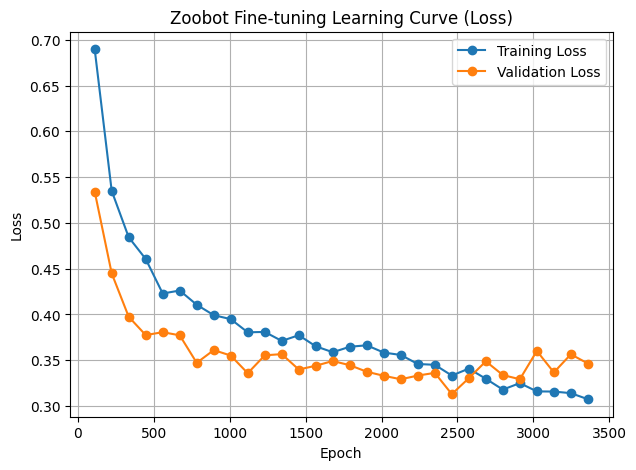

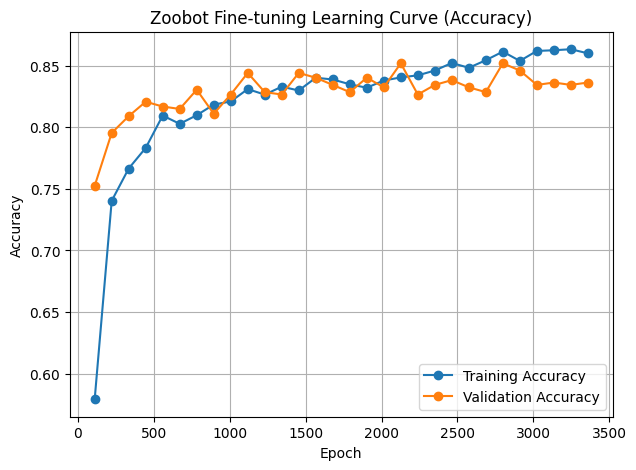

In [50]:
plt.figure(figsize=(7,5))
plt.plot(train_epochs, train_loss, 'o-', label='Training Loss')
plt.plot(val_epochs, val_loss, 'o-', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Zoobot Fine-tuning Learning Curve (Loss)')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(7,5))
plt.plot(train_epochs_acc, train_acc, 'o-', label='Training Accuracy')
plt.plot(val_epochs_acc, val_acc, 'o-', label='Validation Accuracy')
plt.xlabel('Epoch') # en realidad no son epochs son steps ._.
plt.ylabel('Accuracy')
plt.title('Zoobot Fine-tuning Learning Curve (Accuracy)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# this next part is for the learning curve for different train data percentages use
# i recommend doing it after the final predictions part (i will highlight it)

In [82]:
from sklearn.model_selection import train_test_split

In [83]:
# train and validation
train_catalog, val_catalog = train_test_split(catalog, test_size=0.2, stratify=catalog['jellyfish'], random_state=42)

In [84]:
fractions = [0.1,0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] # % of training sample used

In [85]:
from zoobot.pytorch.training.finetune import FinetuneableZoobotClassifier, get_trainer
from galaxy_datasets.pytorch.galaxy_datamodule import CatalogDataModule
from galaxy_datasets.transforms import default_view_config, get_galaxy_transform

In [86]:
results = [] # here we'll save the info (fraction of sample, accuracy, loss)

In [87]:

for frac in fractions:
    print(f"\n Training with {int(frac*100)}% of data")
    
    # stratified sampling by jellyfish class
    subset = (
        train_catalog
        .groupby('jellyfish', group_keys=False)
        .apply(lambda x: x.sample(frac=frac, random_state=42))
    )
    
    transform_cfg = default_view_config()
    transform = get_galaxy_transform(transform_cfg)
    
    datamodule = CatalogDataModule(
        label_cols=['jellyfish'],
        catalog=pd.concat([subset, val_catalog]),  # full dataset = subset + val
        train_transform=transform,
        test_transform=transform,
        batch_size=32,
        num_workers=2
    )
    
    model = FinetuneableZoobotClassifier(
        name='hf_hub:mwalmsley/zoobot-encoder-convnext_nano',
        training_mode="head_only",  # faster than full fine-tune (found in https://zoobot.readthedocs.io/en/latest/guides/choosing_parameters.html -> training mode)
        learning_rate=1e-5,
        num_classes=2,
        label_col='jellyfish'
    )
    
    trainer = get_trainer(
        save_dir=f'/kaggle/working/learning_curve_frac_{int(frac*100)}',
        max_epochs=8,
        accelerator="gpu",
        devices=1
    )
    
    trainer.fit(model, datamodule)
    
    # extract loss and accuracy like before
    val_acc = float(trainer.callback_metrics['finetuning/val_acc'])
    val_loss = float(trainer.callback_metrics['finetuning/val_loss'])
    
    results.append({'fraction': frac, 'val_acc': val_acc, 'val_loss': val_loss})



🚀 Training with 10% of data


/tmp/ipykernel_157/512315031.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=frac, random_state=42))
INFO: GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:751: Checkpoint directory /kaggle/working/learning_curve_frac_10/checkpoints exists and is not empty.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
INFO: 
  | Name              | Type           | Params | Mode 
-------------------------------------------------------------
0 | encoder           | ConvNeXt       | 15.0 M | train
1 | train_loss_metric | MeanMetric     | 0      | train


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

INFO: Epoch 5, global step 672: 'finetuning/val_loss' reached 0.56501 (best 0.56501), saving model to '/kaggle/working/learning_curve_frac_100/checkpoints/5.ckpt' as top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 6, global step 784: 'finetuning/val_loss' reached 0.54403 (best 0.54403), saving model to '/kaggle/working/learning_curve_frac_100/checkpoints/6.ckpt' as top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 7, global step 896: 'finetuning/val_loss' reached 0.53162 (best 0.53162), saving model to '/kaggle/working/learning_curve_frac_100/checkpoints/7-v3.ckpt' as top 1
INFO: `Trainer.fit` stopped: `max_epochs=8` reached.


In [88]:
results_df = pd.DataFrame(results)

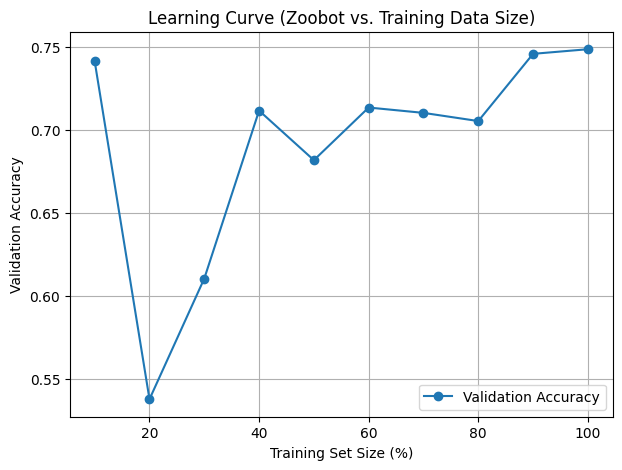

In [89]:
plt.figure(figsize=(7,5))
plt.plot(results_df['fraction'] * 100, results_df['val_acc'], 'o-', label='Validation Accuracy')
plt.xlabel('Training Set Size (%)')
plt.ylabel('Validation Accuracy')
plt.title('Learning Curve (Zoobot vs. Training Data Size)')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# do this part before the above learning curve diagnostic (as to only make predictions with the first training results and not the iterations made for the diagnostic of training sizes)
# i should move this part above the diagnostic but i'm scared it might not work or i break something hehe

In [40]:
# now we can load the best checkpoint and make predictions
best_checkpoint = trainer.checkpoint_callback.best_model_path
finetuned_model = FinetuneableZoobotClassifier.load_from_checkpoint(best_checkpoint)

In [41]:
from zoobot.pytorch.predictions import predict_on_catalog

predictions = predict_on_catalog.predict(
  catalog,
  finetuned_model,
  inference_transform=transform,
  # CAREFUL! For classification, we unpack a single column like [1, 0, 1, 2, ...] into N classes automatically
  # but when making predictions, we make a prediction per class, so (unlike for training) this prediction `label_cols` needs n_classes entries
  # e.g. [class_for_label_0, class_for_label_1, ...
  label_cols=['not_jelly_pred', 'jelly_pred'],  # name the output columns
  save_loc=os.path.join(save_dir, 'finetuned_predictions.csv'),  # optionally, save here
  trainer_kwargs={'accelerator': 'gpu'},
  datamodule_kwargs={'num_workers': 2, 'batch_size': 32},
)

INFO: Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Output()

In [42]:
predictions.head()

,not_jelly_pred,jelly_pred,id_str
0,0.994051,0.005949,10995138971313453
1,0.135031,0.864969,10995128309454767
2,0.958442,0.041558,9906627718811868
3,0.013949,0.986051,9906623870077550
4,0.188522,0.811478,9907733339440855


In [43]:
predictions = pd.merge(predictions, catalog[['id_str', 'jellyfish','filename', 'file_loc']], how='inner', on='id_str')
predictions.head()

,not_jelly_pred,jelly_pred,id_str,jellyfish,filename,file_loc
0,0.994051,0.005949,10995138971313453,0,10995138971313453_0.25_stamp.jpg,/kaggle/input/full-sample/full_sample/10995138...
1,0.135031,0.864969,10995128309454767,1,10995128309454767_0.25_stamp.jpg,/kaggle/input/full-sample/full_sample/10995128...
2,0.958442,0.041558,9906627718811868,0,9906627718811868_0.25_stamp.jpg,/kaggle/input/full-sample/full_sample/99066277...
3,0.013949,0.986051,9906623870077550,1,9906623870077550_0.25_stamp.jpg,/kaggle/input/full-sample/full_sample/99066238...
4,0.188522,0.811478,9907733339440855,1,9907733339440855_0.25_stamp.jpg,/kaggle/input/full-sample/full_sample/99077333...


In [49]:
def show_jellies(df):
  # little utility function to visualise galaxies and our ring labels/predictions

  fig, axes = plt.subplots(ncols=5, figsize=(16, 3))
  for n in range(5):
    galaxy = df.iloc[n]

    im = Image.open(galaxy['file_loc'])
    axes[n].imshow(im)

    correct = np.around(galaxy['jelly_pred']) == galaxy['jellyfish']
    if correct:
      color = 'g'
    else:
      color = 'r'
    axes[n].text(20, 50, 'Pred: {:.2f}'.format(galaxy['jelly_pred']), color=color)
    axes[n].text(20, 90, 'Label: {}'.format(galaxy['jellyfish']), color=color)

    axes[n].axis('off')

2707     9906616658431712
29      10995120037763798
4707    10995137745724341
4723    10995139050537697
1874    10995127900511488
              ...        
4912     9906612034931115
1792    10995127401061119
2804     9906603809836155
494      9906621184085210
2400     9906623070145471
Name: id_str, Length: 5130, dtype: object


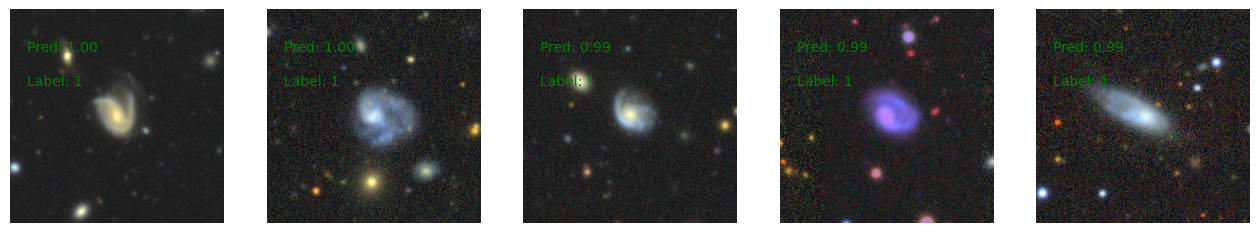

In [50]:
top_5_predictions = predictions.sort_values('jelly_pred', ascending=False)
show_jellies(top_5_predictions)
print(top_5_predictions['id_str'])

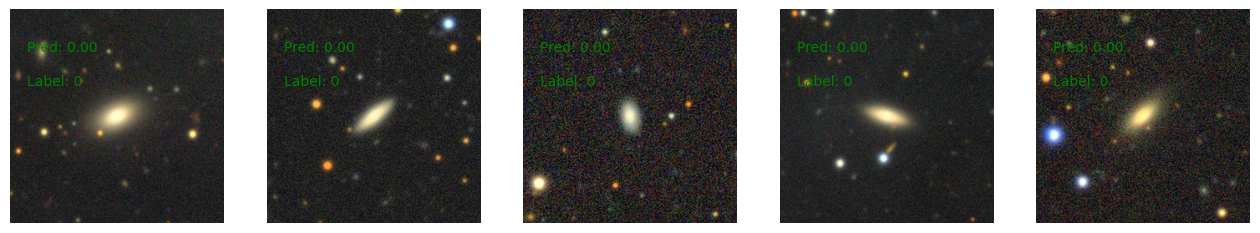

In [58]:
bottom_5_predictions = predictions.sort_values('jelly_pred', ascending=True)
show_jellies(bottom_5_predictions)

4828    10995127733198259
4132    10995126704868055
2181     9906604178280573
5004     9906631167576283
1644    10995126505577081
Name: id_str, dtype: object


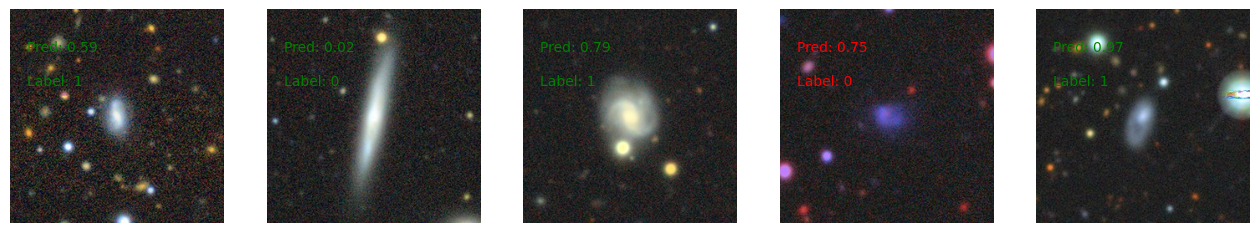

In [51]:
random_predictions = predictions.sample(5, random_state=40)
print(random_predictions['id_str'])
show_jellies(random_predictions)

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [53]:
predictions['pred_class'] = np.argmax(predictions[['not_jelly_pred', 'jelly_pred']].values, axis=1)

In [54]:
predictions

,not_jelly_pred,jelly_pred,id_str,jellyfish,filename,file_loc,pred_class
0,0.994051,0.005949,10995138971313453,0,10995138971313453_0.25_stamp.jpg,/kaggle/input/full-sample/full_sample/10995138...,0
1,0.135031,0.864969,10995128309454767,1,10995128309454767_0.25_stamp.jpg,/kaggle/input/full-sample/full_sample/10995128...,1
2,0.958442,0.041558,9906627718811868,0,9906627718811868_0.25_stamp.jpg,/kaggle/input/full-sample/full_sample/99066277...,0
3,0.013949,0.986051,9906623870077550,1,9906623870077550_0.25_stamp.jpg,/kaggle/input/full-sample/full_sample/99066238...,1
4,0.188522,0.811478,9907733339440855,1,9907733339440855_0.25_stamp.jpg,/kaggle/input/full-sample/full_sample/99077333...,1
...,...,...,...,...,...,...,...
5125,0.860794,0.139206,10995128321380465,0,10995128321380465_0.25_stamp.jpg,/kaggle/input/full-sample/full_sample/10995128...,0
5126,0.026728,0.973272,9906618034226819,1,9906618034226819_0.25_stamp.jpg,/kaggle/input/full-sample/full_sample/99066180...,1
5127,0.964738,0.035262,9906614384857090,0,9906614384857090_0.25_stamp.jpg,/kaggle/input/full-sample/full_sample/99066143...,0
5128,0.270108,0.729892,10995127225422124,0,10995127225422124_0.25_stamp.jpg,/kaggle/input/full-sample/full_sample/10995127...,1


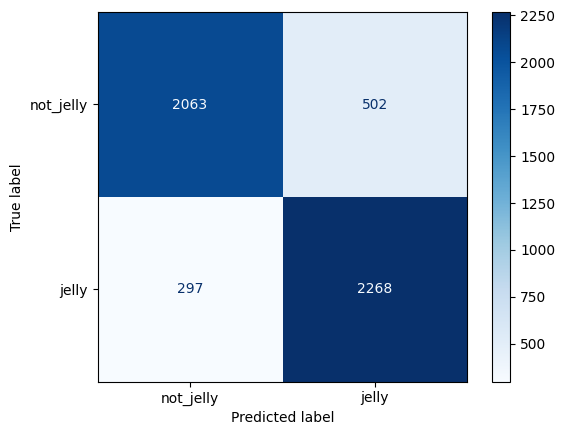

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = predictions['jellyfish'].values
y_pred = predictions['pred_class'].values
class_names = ['not_jelly', 'jelly']

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

precision = precision_score(y_true, y_pred)
print("Precision:", precision)

recall = recall_score(y_true, y_pred)
print("Recall:", recall)

f1 = f1_score(y_true, y_pred)
print("F1 Score:", f1)

Accuracy: 0.8442495126705652
Precision: 0.8187725631768953
Recall: 0.8842105263157894
F1 Score: 0.8502343017806935


In [58]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(predictions['jellyfish'], predictions['jelly_pred'])
print('ROC AUC:', auc)

ROC AUC: 0.924483734786392


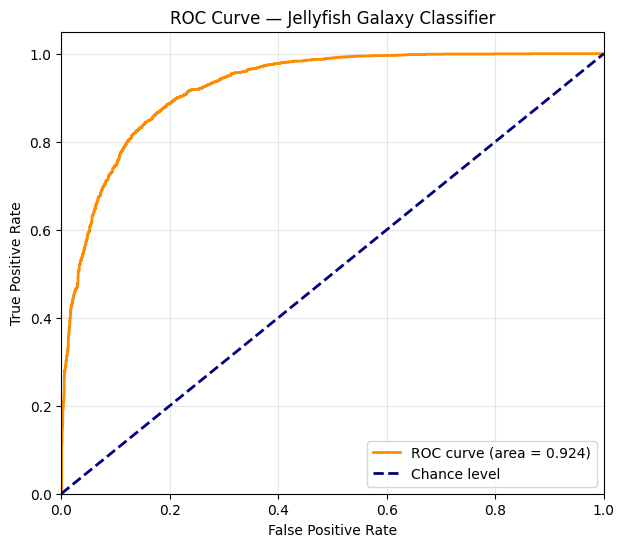

In [60]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_true = predictions['jellyfish']
y_score = predictions['jelly_pred']

fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chance level')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Jellyfish Galaxy Classifier')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# to download images depending on predicted label

# directories for the output images

fp_dir = "/kaggle/working/false_positives"
fn_dir = "/kaggle/working/false_negatives"
tp_dir = "/kaggle/working/true_positives"
tn_dir = "/kaggle/working/true_negatives"

# reset directory to avoid duplicates
def reset_dir(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)

# reset all output folders
for d in [fp_dir, fn_dir, tp_dir, tn_dir]:
    reset_dir(d)

# identify confusion matrix labels
false_positives = predictions[
    (predictions["jellyfish"] == 0) & (predictions["pred_class"] == 1)
]

false_negatives = predictions[
    (predictions["jellyfish"] == 1) & (predictions["pred_class"] == 0)
]

true_positives = predictions[
    (predictions["jellyfish"] == 1) & (predictions["pred_class"] == 1)
]

true_negatives = predictions[
    (predictions["jellyfish"] == 0) & (predictions["pred_class"] == 0)
]

print(f"True Positives:  {len(true_positives)}")
print(f"True Negatives:  {len(true_negatives)}")
print(f"False Positives: {len(false_positives)}")
print(f"False Negatives: {len(false_negatives)}")

# helps copy files
def copy_images(df, out_dir):
    for _, row in df.iterrows():
        src = row["file_loc"]
        dst = os.path.join(out_dir, os.path.basename(src))
        if os.path.exists(src):
            shutil.copy(src, dst)

# use copy function
copy_images(false_positives, fp_dir)
copy_images(false_negatives, fn_dir)
copy_images(true_positives, tp_dir)
copy_images(true_negatives, tn_dir)

print("TP, TN, FP, and FN images copied")

# put results as zip for download
shutil.make_archive("/kaggle/working/false_positives", "zip", fp_dir)
shutil.make_archive("/kaggle/working/false_negatives", "zip", fn_dir)
shutil.make_archive("/kaggle/working/true_positives", "zip", tp_dir)
shutil.make_archive("/kaggle/working/true_negatives", "zip", tn_dir)